# Seq2Seq for Language Translation

In this tutorial you will implement a language-translation model to translate (simple) sentences from French to English.
The translation data come from [here](https://www.manythings.org/anki/).

Language translation can be treated as a sequence-to-sequence task---any model that is trained to perform this type of tasks is known as Seq2Seq (Sutskever et al., 2014).
A Seq2Seq model predicts following this procedure (see figure below): (1) Take in the source data, here the French sentence, and compress the data into a latent vector. (2) Condition on this latent vector, autoregressively generate the ouput, here the English sentence.
![seq2seq](seq2seq_diag.png)
To indicate the start of the sequence (SOS), we use `SOS_TOKEN`, while to indicate the end of the sequence (EOS), we use `EOS_TOKEN`.

Formally, we can formulate this using the following Bayes' Net:
$$
P(Y_1, \dots, Y_N | X_1, \dots, X_M) = P(V | X_1, \dots, X_M) \prod_{n=1}^N P(Y_n | V, Y_1, \dots, Y_{n - 1})
$$
In other words, we first compress the source sequence, $X_1, \dots, X_M$, into a latent vector $V$, and generate the output sequence $Y_1, \dots, Y_N$ autoregressively, given the latent vector $V$ as the context.
Here, the model $P$ can be a RNN, a transformer, or any memory-based models---in this tutorial we will consider a vanilla RNN and a transformer (Vaswani et al., 2017).
In particular the transformer follows a GPT-style architecture (Radford et al., 2019).

During the decoding phase, note that the $n$'th output is modelled as $P(Y_n | V, Y_1, \dots, Y_{n - 1})$.
Given a dataset of sequences, where each sequence can be represented as $\{x_1, \dots, x_n, t_1, \dots, t_m\}$, we can generate the predictions $Y_1, \dots, Y_{n - 1}$ in two ways during training:
1. `y_1 = argmax P(Y_1 | V, SOS_TOKEN)`, `y_2 = argmax P(Y_2 | V, SOS_TOKEN, Y_1 = y_1)`, and so on
2. `y_1 = argmax P(Y_1 | V, SOS_TOKEN)`, `y_2 = argmax P(Y_2 | V, SOS_TOKEN, Y_1 = t_1)`, and so on

The first approach uses the model's predictions for decoding---this is done *autoregressively*.
The second approach is known as *teacher forcing* as we use the ground-truth label rather than the model's prediction for decoding (What can go wrong with this?).
Note that we always pass in `SOS_TOKEN` in the beginning as our models require some input for inference.

Your task is to complete the `forward` call for both the `DecoderRNN` and `DecoderTransformer` in `model.py`.
The `forward` call should handle inference based on whether teacher forcing is enabled.

### References
- Sutskever et al. (2014): https://arxiv.org/pdf/1409.3215
- Vaswani et al. (2017): https://arxiv.org/pdf/1706.03762
- Radford et al. (2019): https://insightcivic.s3.us-east-1.amazonaws.com/language-models.pdf

### Credits
Bryan Chan, Nov. 2024  

In [1]:
%matplotlib inline
from IPython.display import display, clear_output

import _pickle as pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch
import torch.nn as nn

from models import (
    MAX_LENGTH,
    EOS_TOKEN,
    SOS_TOKEN,
    Seq2SeqModel,
    EncoderRNN,
    DecoderRNN,
    EncoderTransformer,
    DecoderTransformer,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

### Generating French-English Pairs

In [2]:
def data_generator(
    batch_size,
    seed,
):
    """
    Generates a language-translation dataset
    """
    # Process dataset and convert string into integers
    data = pickle.load(open("data.pkl", "rb"))

    samples = data["samples"]

    num_samples = len(samples)
    input_ids = np.zeros((num_samples, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((num_samples, MAX_LENGTH), dtype=np.longlong)

    def words_to_idxes(lang, sentence):
        return [lang["word2id"][word] for word in sentence.split(" ")] + [EOS_TOKEN]

    for sample_i, (input_sentence, target_sentence) in enumerate(samples):
        curr_input_id = words_to_idxes(data["input_lang"], input_sentence)
        curr_output_id = words_to_idxes(data["output_lang"], target_sentence)
        input_ids[sample_i, :len(curr_input_id)] = curr_input_id
        target_ids[sample_i, :len(curr_output_id)] = curr_output_id

    rng = np.random.RandomState(seed)
    def data_iterator():
        while True:
            sample_idx = rng.randint(len(samples), size=(batch_size,))

            yield {
                "input": torch.tensor(input_ids[sample_idx], device=device),
                "target": torch.tensor(target_ids[sample_idx], device=device),
            }
    return data["input_lang"], data["output_lang"], data_iterator

### Training Loop

In [3]:
def train(dataset, model, optimizer, num_iterations, teacher_forcing=True):
    # For plotting
    fig, axes = plt.subplots(1, 3, figsize=(12, 5), layout="constrained")
    axes = axes.flatten()
    fig.suptitle("Training Seq2Seq")
    fig.supxlabel("Iteration")

    param_norms = {k: [] for k, _ in model.named_parameters() if "gpt" not in k and "ln_layer" not in k}
    grad_norms = {k: [] for k, _ in model.named_parameters() if "gpt" not in k and "ln_layer" not in k}
    iterations = []
    losses = []

    # Negative log-likelihood loss, essentially same as cross-entropy with discrete labels
    loss_fn = nn.NLLLoss()
    for iter_i in range(num_iterations):
        batch = next(dataset)

        # Get model predictions
        preds = model(
            batch["input"],
            batch["target"] if teacher_forcing else None,
        )

        loss = loss_fn(preds.reshape(-1, preds.shape[-1]), batch["target"].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # For plotting
        iterations.append(iter_i)
        losses.append(loss.detach().cpu().item())

        # NOTE: To extract the information such as parameter value and its gradient,
        #       you can use model.named_parameters() or model.parameters()
        for k, p in filter(
            lambda layer: layer[1].grad is not None,
            model.named_parameters()
        ):
            # Here we skip the GPT blocks because they have significantly more layers
            if "gpt" in k or "ln_layer" in k:
                continue
            grad_norms[k].append(p.grad.data.norm(2).item())
            param_norms[k].append(p.norm(2).item())

        for ax in axes:
            ax.clear()

        axes[0].set_title("Loss")
        axes[1].set_title("Parameter Norm")
        axes[2].set_title("Gradient Norm")

        axes[0].plot(iterations, losses)

        for k, _ in model.named_parameters():
            if "gpt" in k or "ln_layer" in k:
                continue
            params_v = param_norms[k]
            grads_v = grad_norms[k]
            axes[1].plot(iterations, params_v, label="{}".format(k))
            axes[2].plot(iterations, grads_v, label="{}".format(k))
        axes[2].legend(loc="upper right")

        display(fig)
        clear_output(wait=True)
        plt.pause(0.01)

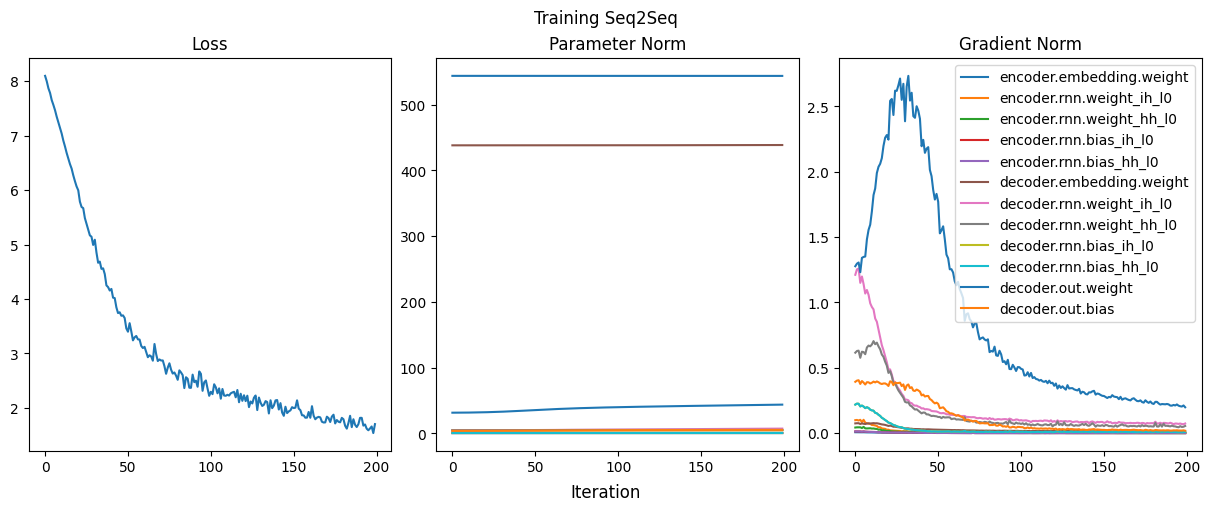

In [4]:
seed = 42

# ============================================================
# TODO: Play around with different hyperparameters
# Training hyperparameters
num_iterations = 200
batch_size = 128
dropout = 0.1

# Dataset
input_lang, output_lang, dataset = data_generator(batch_size, seed)

# Model: Supports {"RNN", "Transformer"}
model_type = "RNN"

# For RNN
hidden_size = 64

# For transformer
embed_dim = 64
num_blocks = 4
num_heads = 4

teacher_forcing = True

# Instantiate optimizer, can use other optimizer such as Adam, RMSProp, etc.
lr = 1e-3
opt_constructor = torch.optim.Adam
# ============================================================

if model_type == "RNN":
    encoder = EncoderRNN(
        len(input_lang["id2word"]),
        hidden_size,
        dropout,
    )
    decoder = DecoderRNN(
        len(output_lang["id2word"]),
        hidden_size,
    )
elif model_type == "Transformer":
    encoder = EncoderTransformer(
        len(input_lang["id2word"]),
        num_blocks,
        embed_dim,
        num_heads,
        dropout=dropout,
    )
    decoder = DecoderTransformer(
        len(output_lang["id2word"]),
        num_blocks,
        embed_dim,
        num_heads,
        dropout=dropout,
    )
else:
    raise NotImplementedError

model = Seq2SeqModel(encoder, decoder)
model.to(device)
optimizer = opt_constructor(model.parameters(), lr)

train(dataset(), model, optimizer, num_iterations, teacher_forcing)

### Evaluate Model
Note that the model has dropout, by setting the model to evaluation mode, `model.eval()`, we turn dropout off.

To evaluate, we simply take the argmax at each step, i.e., greedy sampling.
Can you notice what can go wrong with the translated sentences in this case?

In [6]:
model.eval()

batch = next(dataset())

def idxes_to_sentence(lang, word_idxes):
    """ Converts the list of ids into words """
    tokens = []
    for word_idx in word_idxes:
        if word_idx.item() == EOS_TOKEN:
            tokens.append("<EOS>")
            break
        else:
            tokens.append(lang["id2word"][word_idx.item()])
    return " ".join(tokens)

for sample_i in range(batch_size):
    with torch.no_grad():
        preds = model(batch["input"][[sample_i]])

        # NOTE: Here we take the argmax at each step, i.e. greedy sampling
        #       Alternatively, you may sample at each timestep t.
        preds = torch.argmax(preds, axis=-1)

    print("Sample {} ================".format(sample_i))
    print("Input: {}".format(idxes_to_sentence(input_lang, batch["input"][sample_i])))
    print("Target: {}".format(idxes_to_sentence(output_lang, batch["target"][sample_i])))
    print("Prediction: {}".format(idxes_to_sentence(output_lang, preds[0])))

TypeError: full() received an invalid combination of arguments - got (int, int, device=torch.device, dtype=torch.dtype), but expected one of:
 * (tuple of ints size, Number fill_value, *, tuple of names names, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (tuple of ints size, Number fill_value, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


### Visualizing Attention
Let's check out what the transformer end up attending with its cross attention layers!

In [ ]:
sample_i = 0
attention_i = 0

if model_type == "Transformer":
    def show_attention(input_sentence, output_words, attentions):
        fig = plt.figure()
        ax = fig.add_subplot(111)
        cax = ax.matshow(attentions.cpu().numpy(), cmap='bone')
        fig.colorbar(cax)

        # Set up axes
        ax.set_xticklabels([""] + input_sentence.split(" "), rotation=90)
        ax.set_yticklabels([""] + output_words.split(" "))

        # Show label at every tick
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

        plt.show()
        
    batch = next(dataset())

    # Here we are using the ground-truth target,
    # but we can visualize the same thing during autoregressive inference
    with torch.no_grad():
        attention = model.get_attention(
            batch["input"][[sample_i]],
            batch["target"][[sample_i]],
        )

    show_attention(
        idxes_to_sentence(input_lang, batch["input"][sample_i]),
        idxes_to_sentence(output_lang, batch["target"][sample_i]),
        attention[attention_i][0]
    )
